# 20.000 veces menos hierro que el Sol

Una estrella en el halo de la Nube Mayor de Magallanes tiene tan pocos metales que desafía los modelos de formación estelar. Según el paper, es más de 10 veces más prístina que las galaxias más extremas que ha visto el James Webb.

---

📄 **Paper:** Ezzeddine, R. et al. (2026). *A nearly pristine star from the Large Magellanic Cloud*. Nature Astronomy.
**DOI:** [10.1038/s41550-026-02816-7](https://doi.org/10.1038/s41550-026-02816-7)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-04-estrella-pristina-nube-magallanes/notebook.ipynb)

## Las primeras estrellas no sobrevivieron

Las primeras estrellas del universo se formaron de gas casi puro: hidrógeno y helio, con trazas mínimas de litio. Eran tan masivas que explotaron rápido como supernovas, sembrando los primeros elementos pesados — lo que en astronomía se llama «metales» (todo lo que no sea hidrógeno o helio).

Ninguna de esas estrellas primordiales sigue viva. Pero sus descendientes directas — estrellas de baja masa formadas del gas contaminado por una sola supernova — sí podrían existir hoy. Se reconocen por tener metalicidades extremadamente bajas: la huella química de una sola explosión ancestral.

SDSS J0715−7334 es una de esas candidatas. Un equipo internacional la identificó de forma independiente y analizó su espectro en alta resolución. Lo que encontraron desafía el patrón esperado.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FEH_J0715_NLTE = -4.31       # [Fe/H] NLTE de J0715 (paper: -4.3)
FEH_SOL = 0.0                # [Fe/H] solar por definición
CEMP_THRESHOLD = 0.7         # [C/Fe] > 0.7 = CEMP (Carbon-Enhanced Metal-Poor)
FUENTE = 'Fuente: Ezzeddine et al. (2026), Nat. Astron. | Datos: Zenodo 10.5281/zenodo.18483957'
COLOR_J0715 = '#DC2626'      # Rojo — la estrella protagonista
COLOR_MUESTRA = '#2563EB'    # Azul CaM — muestra comparativa
COLOR_CEMP = '#D97706'       # Amber — estrellas CEMP
COLOR_LIMITE = '#BBBBBB'     # Gris — límites superiores
COLOR_DETECCION = '#2563EB'  # Azul — detecciones

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Cargar estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
abun = pd.read_csv('datos/abundancias_j0715.csv')
muestra = pd.read_csv('datos/muestra_ump.csv')
espectro = pd.read_csv('datos/espectro_j0715.csv')

# Resumen
print(f"J0715-7334 — Huella química")
print(f"  Elementos medidos: {len(abun)}")
print(f"  Detecciones: {(~abun['limit']).sum()}")
print(f"  Límites superiores: {abun['limit'].sum()}")
print(f"  [Fe/H] (NLTE): {FEH_J0715_NLTE}")
print(f"\nMuestra comparativa: {len(muestra)} estrellas ultra metal-poor")
print(f"  [Fe/H] rango: {muestra['[Fe/H]'].min():.2f} a {muestra['[Fe/H]'].max():.2f}")
print(f"  CEMP ([C/Fe] > 0.7): {(muestra['[C/Fe]'] > CEMP_THRESHOLD).sum()} de {len(muestra)}")
print(f"\nEspectro: {len(espectro):,} puntos ({espectro['wavelength'].min():.0f}-{espectro['wavelength'].max():.0f} Å)")

J0715-7334 — Huella química
  Elementos medidos: 22
  Detecciones: 14
  Límites superiores: 8
  [Fe/H] (NLTE): -4.31

Muestra comparativa: 39 estrellas ultra metal-poor
  [Fe/H] rango: -7.30 a -3.90
  CEMP ([C/Fe] > 0.7): 31 de 39

Espectro: 86,464 puntos (3328-9398 Å)


## La huella química de una sola supernova

Aquí está.

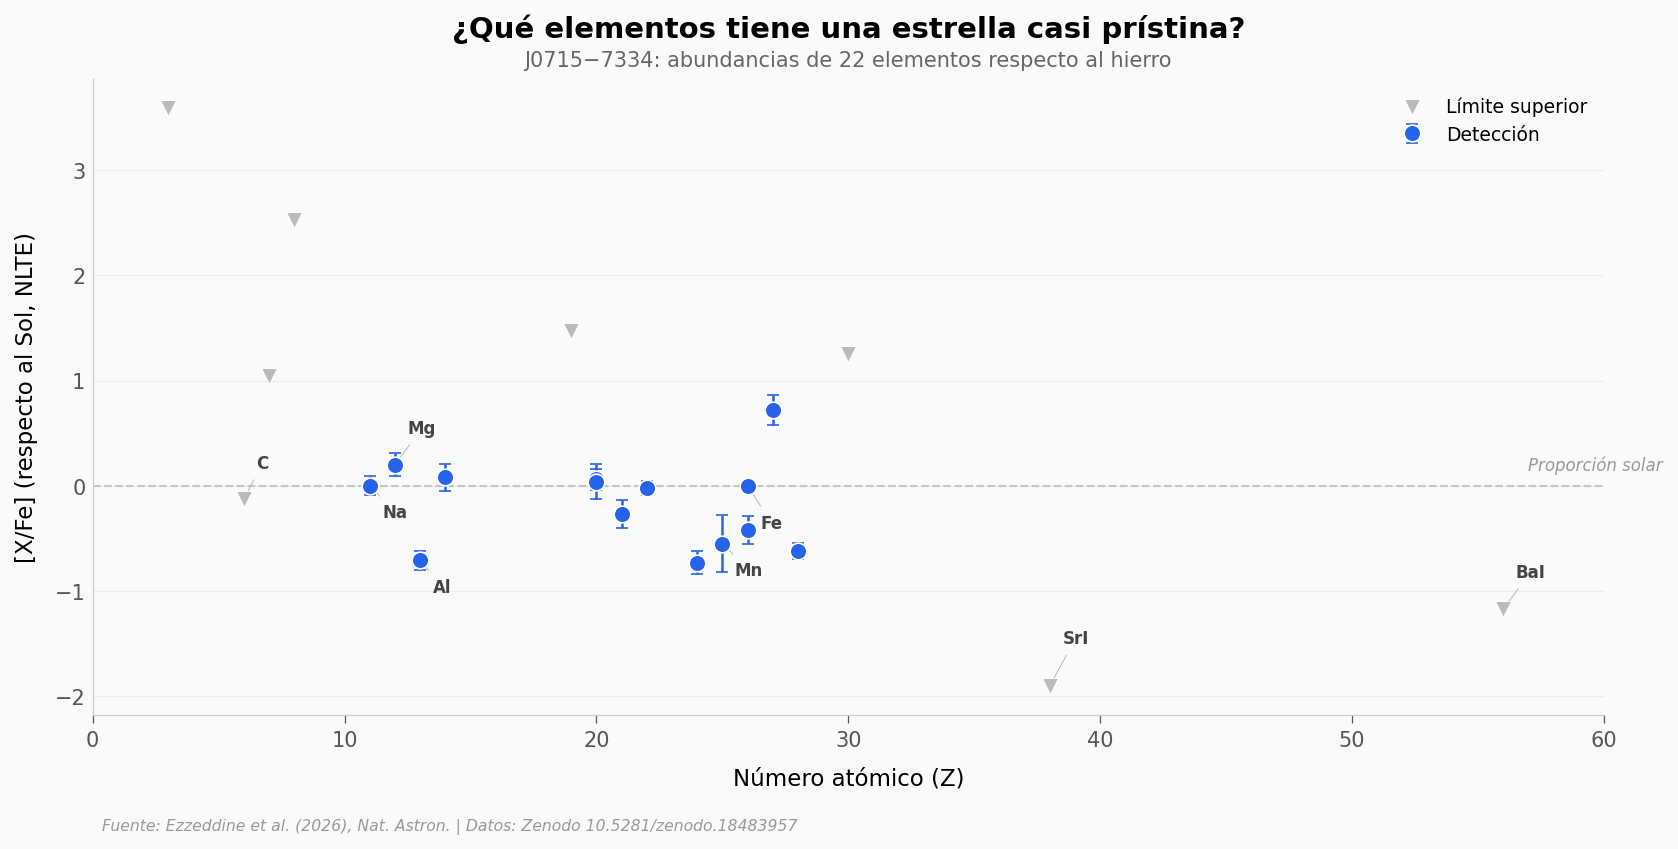

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

det = abun[~abun['limit']].copy()
ul = abun[abun['limit']].copy()

# Detecciones con barras de error
ax.errorbar(det['Z'], det['[X/Fe]_NLTE'], yerr=det['e_XFe'],
            fmt='o', color=COLOR_DETECCION, markersize=8,
            ecolor=COLOR_DETECCION, elinewidth=1.2, capsize=3,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5,
            label='Detección')

# Límites superiores (triángulos invertidos)
ax.scatter(ul['Z'], ul['[X/Fe]_NLTE'], marker='v', s=60,
           color=COLOR_LIMITE, edgecolors='white', linewidths=0.5,
           zorder=4, label='Límite superior')

# Línea solar [X/Fe] = 0
ax.axhline(y=0, color='#999999', linewidth=1, linestyle='--', alpha=0.5)
ax.text(57, 0.15, 'Proporción solar', fontsize=8, color='#999999', style='italic')

# Etiquetas de elementos clave
labels_to_show = {'Fe I': (26, -0.4), 'C-H': (6, 0.3), 'Mg I': (12, 0.3),
                  'Mn I': (25, -0.3), 'Sr II': (38, 0.4), 'Ba II': (56, 0.3),
                  'Na I': (11, -0.3), 'Al I': (13, -0.3)}
for _, row in abun.iterrows():
    if row['elem'] in labels_to_show:
        dx, dy = 0, labels_to_show[row['elem']][1]
        ax.annotate(row['elem'].replace(' I', '').replace(' II', '').replace('-H', ''),
                    xy=(row['Z'], row['[X/Fe]_NLTE']),
                    xytext=(row['Z'] + 0.5, row['[X/Fe]_NLTE'] + dy),
                    fontsize=8, color='#444444', fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color='#BBBBBB', lw=0.5))

ax.set_xlabel('Número atómico (Z)', fontsize=11)
ax.set_ylabel('[X/Fe] (respecto al Sol, NLTE)', fontsize=11)
ax.set_title('¿Qué elementos tiene una estrella casi prístina?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'J0715−7334: abundancias de 22 elementos respecto al hierro',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(0, 60)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/huella_quimica.png', dpi=200, bbox_inches='tight')
plt.show()

Los elementos alfa (Mg, Si, Ca, Ti) — los que produce una supernova de colapso de núcleo — están en proporciones casi solares respecto al hierro. El manganeso y el aluminio están por debajo: una firma típica de enriquecimiento por una sola supernova masiva.

Los elementos pesados del proceso-r (estroncio, bario) son límites superiores muy bajos. Esta estrella apenas tiene rastro de los procesos nucleares que producen elementos más allá del hierro.

El patrón completo es consistente con una supernova primordial de unas 30 masas solares.

## La excepción que rompe el patrón

Casi todas las estrellas ultra metal-poor conocidas tienen algo en común: están enriquecidas en carbono. Se llaman estrellas CEMP (*Carbon-Enhanced Metal-Poor*) y se definen por tener [C/Fe] > 0,7 — más carbono del esperado para su nivel de hierro.

Entre las 15 estrellas de la muestra con [Fe/H] < −4,5, **14 son CEMP**. La única que no lo es: J0715−7334.

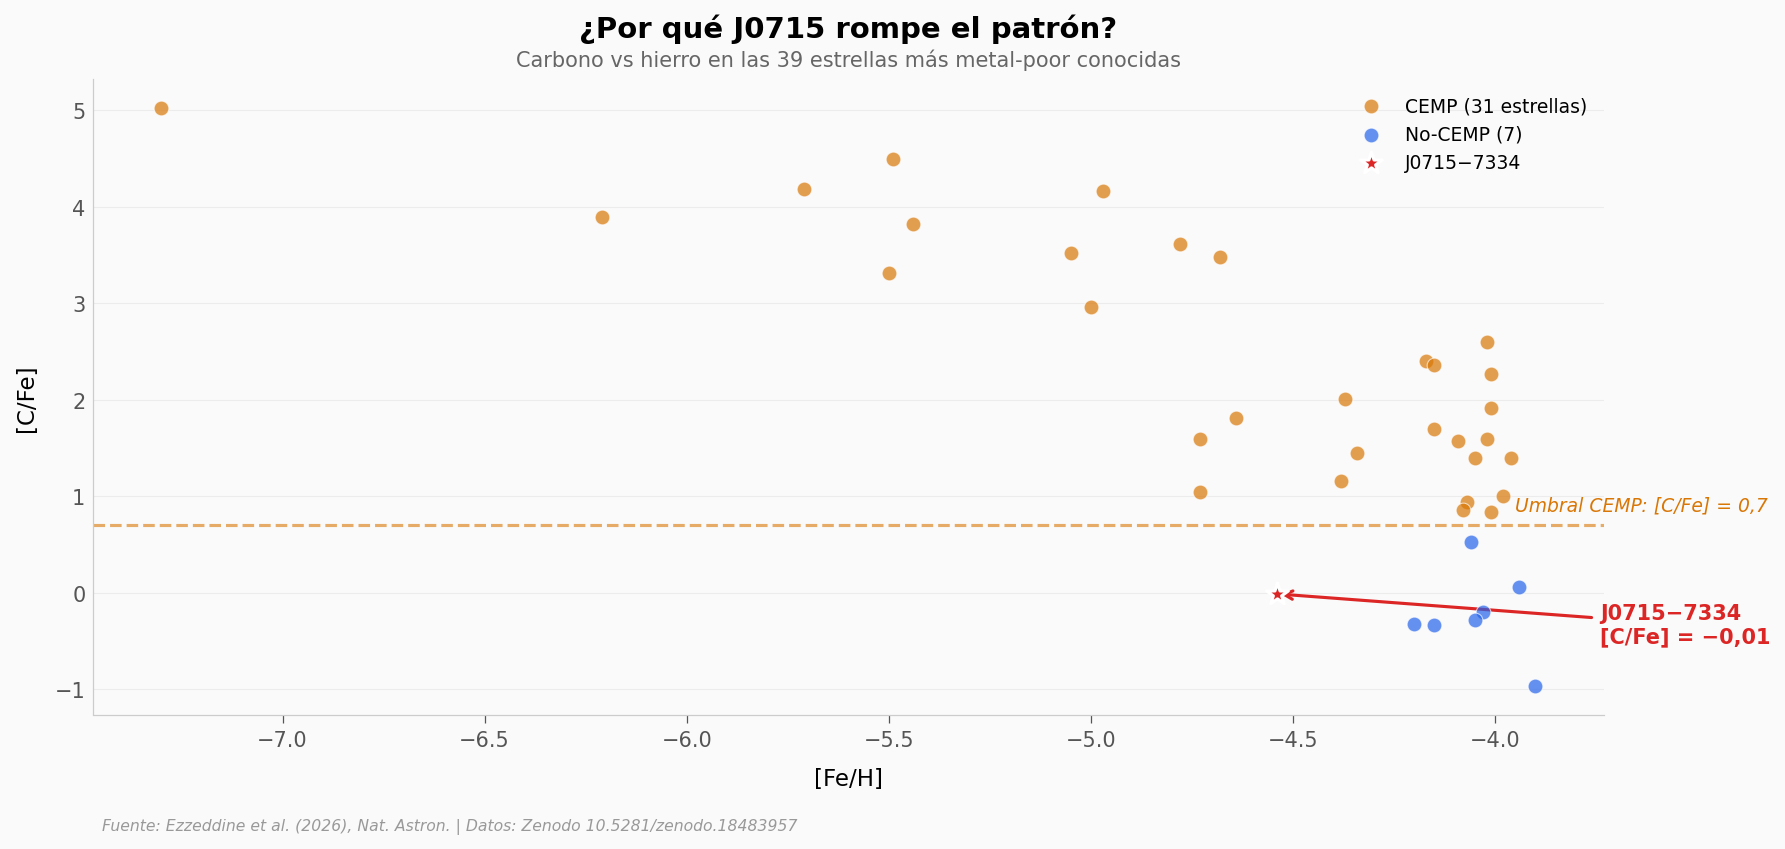

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

j0715_row = muestra[muestra['Name'].str.contains('0715')]
otros = muestra[~muestra['Name'].str.contains('0715')]

# Clasificar CEMP / no-CEMP
cemp = otros[otros['[C/Fe]'] > CEMP_THRESHOLD]
no_cemp = otros[otros['[C/Fe]'] <= CEMP_THRESHOLD]

# Estrellas CEMP
ax.scatter(cemp['[Fe/H]'], cemp['[C/Fe]'], color=COLOR_CEMP, s=50, alpha=0.7,
           edgecolors='white', linewidths=0.5, zorder=4, label=f'CEMP ({len(cemp)} estrellas)')

# Estrellas no-CEMP (sin J0715)
if len(no_cemp) > 0:
    ax.scatter(no_cemp['[Fe/H]'], no_cemp['[C/Fe]'], color=COLOR_MUESTRA, s=50, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=4, label=f'No-CEMP ({len(no_cemp)})')

# J0715 — protagonista
ax.scatter(j0715_row['[Fe/H]'], j0715_row['[C/Fe]'], color=COLOR_J0715, s=120,
           edgecolors='white', linewidths=1.5, zorder=6, marker='*',
           label='J0715−7334')

# Umbral CEMP
ax.axhline(y=CEMP_THRESHOLD, color=COLOR_CEMP, linewidth=1.5, linestyle='--', alpha=0.6)
ax.text(-3.95, 0.85, 'Umbral CEMP: [C/Fe] = 0,7', fontsize=9,
        color=COLOR_CEMP, style='italic')

# Anotación J0715
ax.annotate('J0715−7334\n[C/Fe] = −0,01',
            xy=(j0715_row['[Fe/H]'].values[0], j0715_row['[C/Fe]'].values[0]),
            xytext=(j0715_row['[Fe/H]'].values[0] + 0.8, j0715_row['[C/Fe]'].values[0] - 0.5),
            fontsize=10, fontweight='bold', color=COLOR_J0715,
            arrowprops=dict(arrowstyle='->', color=COLOR_J0715, lw=1.5))

ax.set_xlabel('[Fe/H]', fontsize=11)
ax.set_ylabel('[C/Fe]', fontsize=11)
ax.set_title('¿Por qué J0715 rompe el patrón?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Carbono vs hierro en las 39 estrellas más metal-poor conocidas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/carbono_vs_hierro.png', dpi=200, bbox_inches='tight')
plt.show()

## Un espectro casi vacío

La forma más directa de «ver» la composición de una estrella es su espectro: la luz descompuesta en longitudes de onda. Cada elemento absorbe luz a frecuencias específicas, dejando líneas oscuras. Una estrella con muchos metales tiene un espectro lleno de líneas. J0715 tiene un espectro casi limpio — apenas unas muescas en un continuo suave.

Veamos la región alrededor de las líneas de sodio (Na D), una de las pocas donde se detectan absorciones claras.

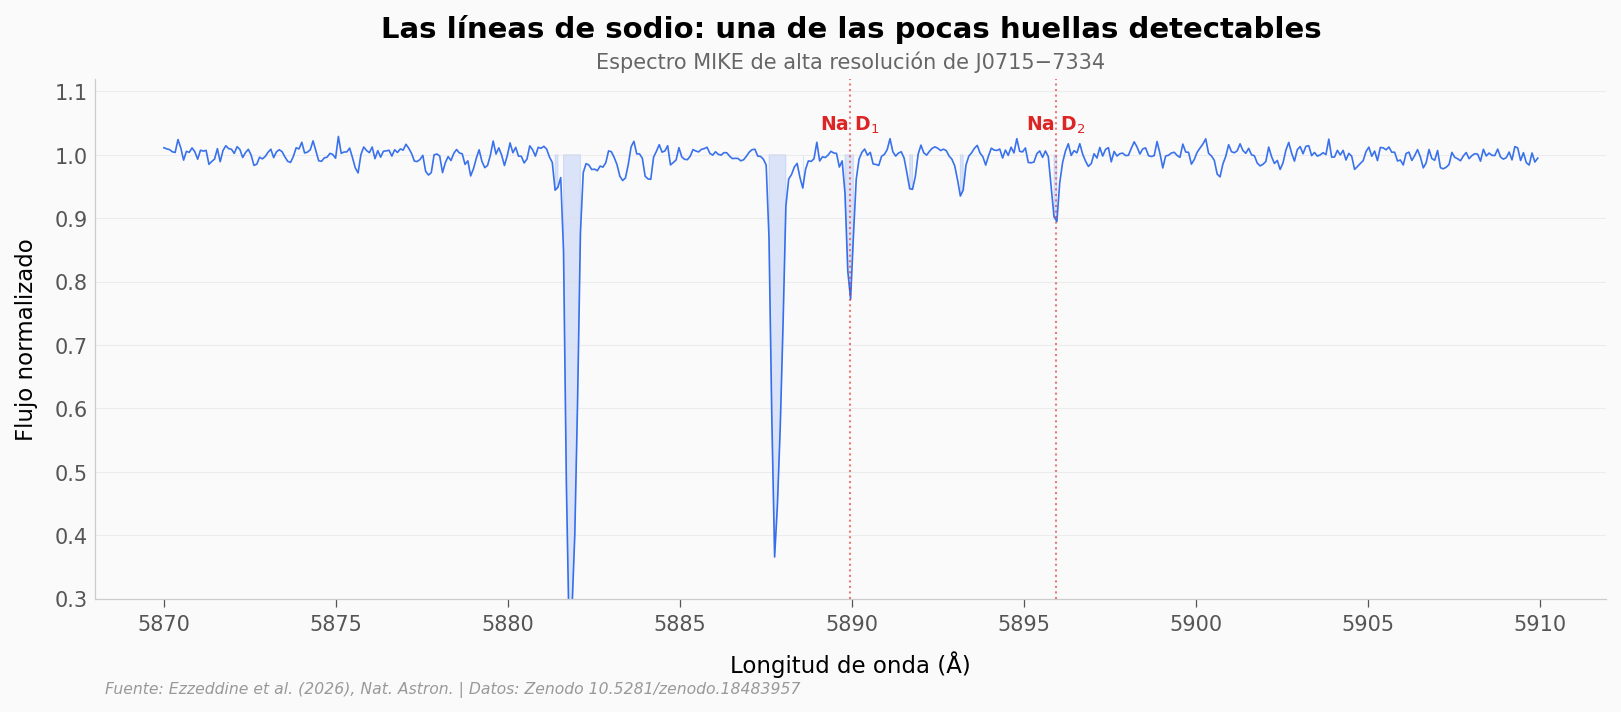

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.5))

# Región Na D (5880-5910 Å) — una de las detecciones más claras
region = espectro[(espectro['wavelength'] >= 5870) & (espectro['wavelength'] <= 5910)]

ax.plot(region['wavelength'], region['flux'], color=COLOR_DETECCION,
        linewidth=0.8, alpha=0.9)
ax.fill_between(region['wavelength'], region['flux'], 1.0,
                where=(region['flux'] < 0.95), color=COLOR_DETECCION, alpha=0.15)

# Marcar líneas Na D
for wl, label in [(5889.95, 'Na D$_1$'), (5895.92, 'Na D$_2$')]:
    ax.axvline(x=wl, color=COLOR_J0715, linewidth=1, linestyle=':', alpha=0.6)
    ax.text(wl, 1.04, label, fontsize=9, color=COLOR_J0715,
            ha='center', fontweight='bold')

ax.set_xlabel('Longitud de onda (Å)', fontsize=11)
ax.set_ylabel('Flujo normalizado', fontsize=11)
ax.set_ylim(0.3, 1.12)
ax.set_title('Las líneas de sodio: una de las pocas huellas detectables',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Espectro MIKE de alta resolución de J0715−7334',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/espectro_na_d.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan rara es esta estrella?

Pongamos en perspectiva su metalicidad. De las 39 estrellas ultra metal-poor de la muestra, veamos dónde cae J0715.

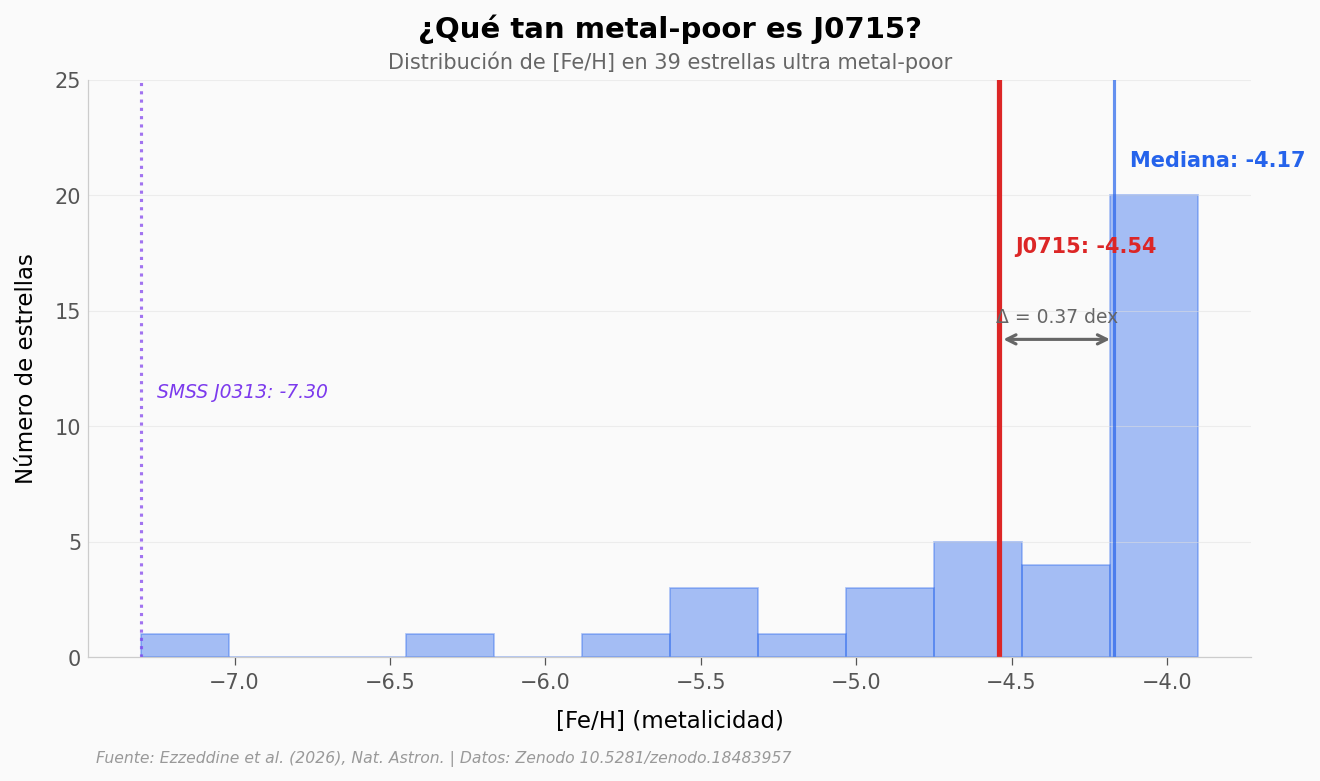

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

feh_values = muestra['[Fe/H]'].values
j0715_feh = muestra[muestra['Name'].str.contains('0715')]['[Fe/H]'].values[0]

n, bins, patches = ax.hist(feh_values, bins=12, color=COLOR_MUESTRA, alpha=0.4,
                           edgecolor=COLOR_MUESTRA, linewidth=0.8)

# Mediana
mediana = np.median(feh_values)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

ax.axvline(x=mediana, color=COLOR_MUESTRA, linewidth=1.5, linestyle='-', alpha=0.7)
ax.text(mediana + 0.05, y_max * 0.85, f'Mediana: {mediana:.2f}',
        fontsize=10, color=COLOR_MUESTRA, fontweight='bold')

# J0715
ax.axvline(x=j0715_feh, color=COLOR_J0715, linewidth=2.5)
ax.text(j0715_feh + 0.05, y_max * 0.7, f'J0715: {j0715_feh:.2f}',
        fontsize=10, color=COLOR_J0715, fontweight='bold')

# Flecha bidireccional
ax.annotate('', xy=(j0715_feh, y_max * 0.55), xytext=(mediana, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = abs(j0715_feh - mediana)
ax.text((j0715_feh + mediana) / 2, y_max * 0.58,
        f'Δ = {diff:.2f} dex', fontsize=9, color='#666666', ha='center')

# La más extrema
min_feh = feh_values.min()
ax.axvline(x=min_feh, color='#7C3AED', linewidth=1.5, linestyle=':', alpha=0.7)
ax.text(min_feh + 0.05, y_max * 0.45, f'SMSS J0313: {min_feh:.2f}',
        fontsize=9, color='#7C3AED', style='italic')

ax.set_xlabel('[Fe/H] (metalicidad)', fontsize=11)
ax.set_ylabel('Número de estrellas', fontsize=11)
ax.set_title('¿Qué tan metal-poor es J0715?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Distribución de [Fe/H] en {len(muestra)} estrellas ultra metal-poor',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_metalicidad.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos respaldan

| Afirmación | ¿Respaldada? | Detalle |
|------------|-------------|---------|
| [Fe/H] ≈ −4,3 | ✅ | Fe I [X/H] = −4,53 (LTE), −4,31 (NLTE). El paper usa NLTE → −4,3 coincide |
| No es CEMP ([C/Fe] < 0,7) | ✅ | [C/Fe] = −0,02 (LTE, límite superior). La única no-CEMP entre las 15 UMP con [Fe/H] < −4,5 |
| Patrón consistente con SN de 30 M☉ | ⚠️ | Los datos muestran el patrón [X/Fe]: alfas casi solares (media +0,08), Mn bajo, sin proceso-r. El ajuste a 30 M☉ es del paper (modelo teórico, no verificable con estos datos solos) |
| Origen en la Nube Mayor de Magallanes | ⚠️ | Los datos cinemáticos (Rperi ≈ 22 kpc, Lz ≈ 0,15) son consistentes pero la membresía a la LMC depende del modelo de potencial gravitatorio usado |
| 10× más prístina que galaxias JWST | ⚠️ | No verificable con estos datos. Es una comparación del paper con metalicidades de galaxias de alto redshift |

> **Limitaciones:** (1) Los datos son NLTE, pero algunas correcciones (ej. Co, +0,88 dex) son grandes — la abundancia NLTE puede depender fuertemente del modelo atmosférico. (2) La muestra comparativa (39 estrellas) es pequeña — representa las más estudiadas, no un censo completo. (3) Varios elementos son límites superiores, no detecciones directas. (4) La membresía a la LMC depende del potencial gravitatorio asumido.

## Ahora tú

1. **¿Qué pasa si subes el umbral CEMP?** Cambia `CEMP_THRESHOLD` a 1.0 o 1.5 en la celda de configuración. ¿Cuántas estrellas siguen siendo CEMP? ¿J0715 sigue siendo la excepción?

2. **¿Qué región del espectro es más «vacía»?** Prueba cambiar el rango de longitud de onda en la celda del espectro (ej: 4000-4100 Å para la línea de Ca II K, o 6550-6575 Å para Hα).

3. **¿Hay correlación entre [Fe/H] y [C/Fe]?** ¿Las estrellas más metal-poor tienden a tener más carbono? Explora con `muestra[['[Fe/H]', '[C/Fe]']].corr(method='spearman')`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto carbono «extra» tienen las CEMP respecto a J0715?
cemp_stars = muestra[muestra['[C/Fe]'] > CEMP_THRESHOLD]
j0715_cfe = muestra[muestra['Name'].str.contains('0715')]['[C/Fe]'].values[0]

print(f"J0715 [C/Fe]: {j0715_cfe:.2f}")
print(f"CEMP mediana [C/Fe]: {cemp_stars['[C/Fe]'].median():.2f}")
print(f"CEMP rango [C/Fe]: {cemp_stars['[C/Fe]'].min():.2f} a {cemp_stars['[C/Fe]'].max():.2f}")
print(f"\nDiferencia mediana: {cemp_stars['[C/Fe]'].median() - j0715_cfe:.2f} dex")
print(f"Eso equivale a ~{10**(cemp_stars['[C/Fe]'].median() - j0715_cfe):.0f}× más carbono (relativo al hierro)")

# Correlación Spearman [Fe/H] vs [C/Fe]
from scipy import stats
rho, p = stats.spearmanr(muestra['[Fe/H]'], muestra['[C/Fe]'])
print(f"\nSpearman ρ ([Fe/H] vs [C/Fe]): {rho:.3f} (p = {p:.4f}, n = {len(muestra)}, ρ² = {rho**2:.3f})")
print(f"{'Correlación significativa' if p < 0.05 else 'Sin correlación significativa'}")

J0715 [C/Fe]: -0.01
CEMP mediana [C/Fe]: 2.01
CEMP rango [C/Fe]: 0.84 a 5.02

Diferencia mediana: 2.02 dex
Eso equivale a ~105× más carbono (relativo al hierro)



Spearman ρ ([Fe/H] vs [C/Fe]): -0.675 (p = 0.0000, n = 39, ρ² = 0.456)
Correlación significativa


---

## Créditos

- **Paper:** Ezzeddine, R. et al. (2026). *A nearly pristine star from the Large Magellanic Cloud*. Nature Astronomy. DOI: [10.1038/s41550-026-02816-7](https://doi.org/10.1038/s41550-026-02816-7)
- **Datos:** [Zenodo — 10.5281/zenodo.18483957](https://doi.org/10.5281/zenodo.18483957) — espectro normalizado, abundancias, muestra comparativa
- **Licencia datos:** Creative Commons Attribution 4.0
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)